In [1]:
import numpy as np
import pandas as pd
from pyg_dataset import NetlistDataset

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

In [2]:
dataset = NetlistDataset(data_dir="../data/superblue", load_pd = True, load_pe = True, pl = True, processed = True, load_indices=None)

  0%|          | 0/12 [00:00<?, ?it/s]c:\Users\rebal\chip-design\src\pyg_dataset.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(data_load_fp)
100%|██

In [8]:
node_features = []
node_demand = []
node_congestion = []
for i in [0, 1, 2, 3, 6, 7, 8, 9, 10, 11]:
    node_features.append(dataset[i].node_features.cpu().numpy())
    node_demand.append(dataset[i].node_demand.cpu().numpy())
    node_congestion.append(dataset[i].node_congestion.cpu().numpy())

train_features = np.concatenate(node_features)
train_demand = np.concatenate(node_demand)
train_congestion = np.concatenate(node_congestion)

test_features = dataset[5].node_features.cpu().numpy()
test_demand = dataset[5].node_demand.cpu().numpy()
test_congestion = dataset[5].node_congestion.cpu().numpy()

idx = np.random.choice(a=[True, False], p=[0.2, 0.8], size=train_features.shape[0])
train_features = train_features[idx]
train_congestion = train_congestion[idx]

In [9]:
train_features.shape

(1740123, 45)

In [11]:
parameters = {
    'n_estimators': [51, 71],
    'max_depth': [50, 60],
    'max_features': [10, 15]
}

best_fscore_0 = 0
best_fscore_1 = 0
outputs_0 = {}
outputs_1 = {}
for i in parameters['n_estimators']:
    for j in parameters['max_depth']:
        for k in parameters['max_features']:
            print(f'Fitting n_estimators={i}, max_depth={j}, max_features={k}')
            model = RandomForestClassifier(n_estimators=i, max_depth=j, max_features=k, n_jobs=20, class_weight='balanced', random_state=1)
            model.fit(train_features, train_congestion)
            pred = model.predict(test_features)
            print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
            print('Precision 0: \t', precision_score(test_congestion, pred, pos_label=0))
            print('Recall 0: \t', recall_score(test_congestion, pred, pos_label=0))
            print('F score 0: \t', f1_score(test_congestion, pred, pos_label=0))
            print('Precision 1: \t', precision_score(test_congestion, pred, pos_label=1))
            print('Recall 1: \t', recall_score(test_congestion, pred, pos_label=1))
            print('F score 1: \t', f1_score(test_congestion, pred, pos_label=1))
            print()

            if f1_score(test_congestion, pred, pos_label=0) > best_fscore_0:
                best_fscore_0 = f1_score(test_congestion, pred, pos_label=0)
            outputs_0[(i, j, k)] = f1_score(test_congestion, pred, pos_label=0)

            if f1_score(test_congestion, pred, pos_label=1) > best_fscore_1:
                best_fscore_1 = f1_score(test_congestion, pred, pos_label=1)
            outputs_1[(i, j, k)] = f1_score(test_congestion, pred, pos_label=1)

Fitting n_estimators=51, max_depth=50, max_features=10
Confusion Matrix: 
 [[ 29026 152873]
 [ 46269 267066]]
Precision 0: 	 0.38549704495650444
Recall 0: 	 0.15957207021478953
F score 0: 	 0.2257128859926748
Precision 1: 	 0.6359637947416172
Recall 1: 	 0.8523337641821054
F score 1: 	 0.728420754042827

Fitting n_estimators=51, max_depth=50, max_features=15
Confusion Matrix: 
 [[ 30036 151863]
 [ 44954 268381]]
Precision 0: 	 0.4005334044539272
Recall 0: 	 0.16512460211436017
F score 0: 	 0.23384418951375885
Precision 1: 	 0.638631366539439
Recall 1: 	 0.856530550369413
F score 1: 	 0.7317030612926487

Fitting n_estimators=51, max_depth=60, max_features=10
Confusion Matrix: 
 [[ 28098 153801]
 [ 53899 259436]]
Precision 0: 	 0.3426710733319512
Recall 0: 	 0.15447033793478798
F score 0: 	 0.21294752478249007
Precision 1: 	 0.627814063116323
Recall 1: 	 0.8279828298785645
F score 1: 	 0.714137071067974

Fitting n_estimators=51, max_depth=60, max_features=15
Confusion Matrix: 
 [[  8394 

In [13]:
best_fscore_1

0.7676878950683426

In [15]:
model = RandomForestClassifier(n_estimators=71, max_depth=60, max_features=15, n_jobs=20, class_weight='balanced', random_state=1)
model.fit(train_features, train_congestion)
pred = model.predict(test_features)
print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
print('Precision 0: \t', precision_score(test_congestion, pred, pos_label=0))
print('Recall 0: \t', recall_score(test_congestion, pred, pos_label=0))
print('F score 0: \t', f1_score(test_congestion, pred, pos_label=0))
print('Precision 1: \t', precision_score(test_congestion, pred, pos_label=1))
print('Recall 1: \t', recall_score(test_congestion, pred, pos_label=1))
print('F score 1: \t', f1_score(test_congestion, pred, pos_label=1))

Confusion Matrix: 
 [[  4149 177750]
 [  7406 305929]]
Precision 0: 	 0.3590653396797923
Recall 0: 	 0.022809361238929297
F score 0: 	 0.04289391793397914
Precision 1: 	 0.6325042021671398
Recall 1: 	 0.976363955510875
F score 1: 	 0.7676878950683426


In [33]:
train_features[0]

array([ 1.32000000e+02,  3.99800105e-04,  0.00000000e+00,  0.00000000e+00,
        4.00000000e+00,  1.73489370e-05,  1.81367905e-05, -4.42451652e-04,
       -4.98579990e-04,  1.18413154e-05, -3.66117783e-05, -2.40753507e-05,
       -1.69613311e-04, -1.03775405e-04,  3.63318453e-04,  5.76599956e-01,
        3.78524995e+00,  2.84100842e+00,  2.79030752e+00,  3.36511159e+00,
        9.02127504e-01,  3.12200594e+00,  1.58521950e+00,  7.04433247e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  3.00000000e+00,  5.00000000e+00,  7.00000000e+00,
        9.00000000e+00,  1.70000000e+01,  1.90000000e+01,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00], dtype=float32)

In [64]:
X_train = np.concatenate([train_features[:, :4], train_features[:, 5:]], axis=1)
X_test = np.concatenate([test_features[:, :4], test_features[:, 5:]], axis=1)

# X_train = train_features[:, 1:]
# X_test = test_features[:, 1:]

In [65]:
X_train[0]

array([ 1.32000000e+02,  3.99800105e-04,  0.00000000e+00,  0.00000000e+00,
        1.73489370e-05,  1.81367905e-05, -4.42451652e-04, -4.98579990e-04,
        1.18413154e-05, -3.66117783e-05, -2.40753507e-05, -1.69613311e-04,
       -1.03775405e-04,  3.63318453e-04,  5.76599956e-01,  3.78524995e+00,
        2.84100842e+00,  2.79030752e+00,  3.36511159e+00,  9.02127504e-01,
        3.12200594e+00,  1.58521950e+00,  7.04433247e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.00000000e+00,  5.00000000e+00,  7.00000000e+00,  9.00000000e+00,
        1.70000000e+01,  1.90000000e+01,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00],
      dtype=float32)

In [66]:
model = RandomForestClassifier(n_estimators=71, max_depth=60, max_features=15, n_jobs=20, class_weight='balanced', random_state=1)
model.fit(X_train, train_congestion)
pred = model.predict(X_test)
print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
print('Precision 0: \t', precision_score(test_congestion, pred, pos_label=0))
print('Recall 0: \t', recall_score(test_congestion, pred, pos_label=0))
print('F score 0: \t', f1_score(test_congestion, pred, pos_label=0))
print('Precision 1: \t', precision_score(test_congestion, pred, pos_label=1))
print('Recall 1: \t', recall_score(test_congestion, pred, pos_label=1))
print('F score 1: \t', f1_score(test_congestion, pred, pos_label=1))

Confusion Matrix: 
 [[  4884 177015]
 [ 10029 303306]]
Precision 0: 	 0.32749949708308185
Recall 0: 	 0.026850065146042584
F score 0: 	 0.04963112005365526
Precision 1: 	 0.6314652076423891
Recall 1: 	 0.9679927234429604
F score 1: 	 0.7643261060207446


Baseline:
Precision 0: 	 0.3590653396797923
Recall 0: 	 0.022809361238929297
F score 0: 	 0.04289391793397914
Precision 1: 	 0.6325042021671398
Recall 1: 	 0.976363955510875
F score 1: 	 0.7676878950683426

No Eigenvectors:
Precision 0: 	 0.3908149613169682
Recall 0: 	 0.22161199346890306
F score 0: 	 0.2828395516497395
Precision 1: 	 0.6388871885903165
Recall 1: 	 0.7994638326391881
F score 1: 	 0.7102121705699985

No PD:
Precision 0: 	 0.40754373316130993
Recall 0: 	 0.05904375505087989
F score 0: 	 0.10314426752204062
Precision 1: 	 0.6349628157250987
Recall 1: 	 0.9501715416407359
F score 1: 	 0.7612270779426654

No Node Neighbor Features:
Precision 0: 	 0.33673448247285986
Recall 0: 	 0.1787090638211315
F score 0: 	 0.23349794386481582
Precision 1: 	 0.6253003526478688
Recall 1: 	 0.7956532146105606
F score 1: 	 0.7002652966927094

Cell Type:
Precision 0: 	 0.39855985598559857
Recall 0: 	 0.048686358913462964
F score 0: 	 0.08677291187983481
Precision 1: 	 0.6341693903351698
Recall 1: 	 0.9573491630363669
F score 1: 	 0.7629462236233531

Height:
Precision 0: 	 0.3660767939658924
Recall 0: 	 0.1942451580272569
F score 0: 	 0.2538135243178398
Precision 1: 	 0.6324050201145678
Recall 1: 	 0.8047297620757337
F score 1: 	 0.7082357864815864

Width:
Precision 0: 	 0.37971308506013624
Recall 0: 	 0.0720289831170045
F score 0: 	 0.1210883347812425
Precision 1: 	 0.6336306158283938
Recall 1: 	 0.9316929165270398
F score 1: 	 0.754283883503173

Orientation:
Precision 0: 	 0.3841210050095142
Recall 0: 	 0.10875815699921385
F score 0: 	 0.16951941079943955
Precision 1: 	 0.6346533493189583
Recall 1: 	 0.8987696873952798
F score 1: 	 0.7439658577114047

Degree:
Precision 0: 	 0.32749949708308185
Recall 0: 	 0.026850065146042584
F score 0: 	 0.04963112005365526
Precision 1: 	 0.6314652076423891
Recall 1: 	 0.9679927234429604
F score 1: 	 0.7643261060207446

In [10]:
np.random.seed(1)
model = RandomForestClassifier(n_estimators=71, n_jobs=16, max_features=10, max_depth=50)
model.fit(train_features, train_congestion)

RandomForestClassifier(max_depth=50, max_features=10, n_estimators=71,
                       n_jobs=16)

In [11]:
pred = model.predict(test_features)
print('Prediction: \t', pred)
print('Actual: \t', test_congestion)
print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
print('Precision: \t', precision_score(test_congestion, pred))
print('Recall: \t', recall_score(test_congestion, pred))
print('F score: \t', f1_score(test_congestion, pred))

Prediction: 	 [1 0 1 ... 1 1 1]
Actual: 	 [0 0 0 ... 0 0 0]
Confusion Matrix: 
 [[ 25076 156823]
 [ 39446 273889]]
Precision: 	 0.635898233622467
Recall: 	 0.8741091802703177
F score: 	 0.7362142445302514


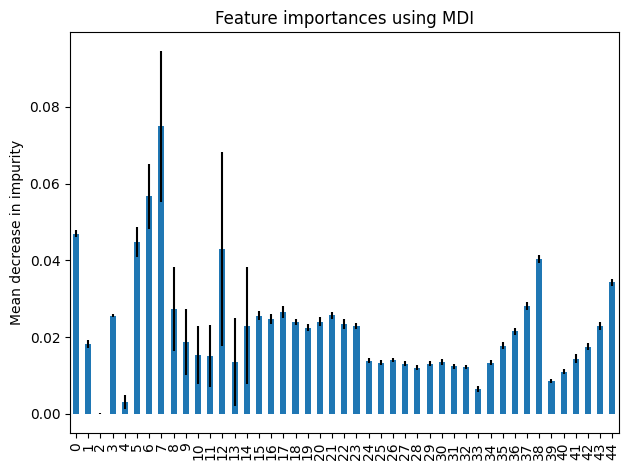

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)
forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [33]:
node_features = []
# node_demand = []
node_congestion = []
for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]:
    node_features.append(dataset[i].node_features.cpu().numpy())
    # node_demand.append(dataset[i].node_demand.cpu().numpy())
    node_congestion.append(dataset[i].node_congestion.cpu().numpy())

train_features = np.concatenate(node_features)
# train_demand = np.concatenate(node_demand)
train_congestion = np.concatenate(node_congestion)

idx = np.random.choice(a=[True, False], p=[0.1, 0.9], size=train_features.shape[0])
train_features = train_features[idx]
train_congestion = train_congestion[idx]

X_train, X_test, y_train, y_test = train_test_split(train_features, train_congestion, random_state=1)

In [34]:
np.random.seed(1)
model = RandomForestClassifier(n_estimators=71, max_depth=None, max_features=15, n_jobs=20, class_weight='balanced')
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Confusion Matrix: \n', confusion_matrix(y_test, pred))
print('Precision 0: \t', precision_score(y_test, pred, pos_label=0))
print('Recall 0: \t', recall_score(y_test, pred, pos_label=0))
print('F score 0: \t', f1_score(y_test, pred, pos_label=0))
print('Precision 1: \t', precision_score(y_test, pred, pos_label=1))
print('Recall 1: \t', recall_score(y_test, pred, pos_label=1))
print('F score 1: \t', f1_score(y_test, pred, pos_label=1))

Confusion Matrix: 
 [[ 59621  32131]
 [ 24061 125568]]
Precision 0: 	 0.7124710212471022
Recall 0: 	 0.6498059987793182
F score 0: 	 0.6796972080668515
Precision 1: 	 0.796251085929524
Recall 1: 	 0.8391956104765788
F score 1: 	 0.8171595168679717


In [22]:
test_features = dataset[4].node_features.cpu().numpy()
test_congestion = dataset[4].node_congestion.cpu().numpy()

pred = model.predict(test_features)
print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
print('Precision 0: \t', precision_score(test_congestion, pred, pos_label=0))
print('Recall 0: \t', recall_score(test_congestion, pred, pos_label=0))
print('F score 0: \t', f1_score(test_congestion, pred, pos_label=0))
print('Precision 1: \t', precision_score(test_congestion, pred, pos_label=1))
print('Recall 1: \t', recall_score(test_congestion, pred, pos_label=1))
print('F score 1: \t', f1_score(test_congestion, pred, pos_label=1))

Confusion Matrix: 
 [[ 17278 162054]
 [ 31561 248602]]
Precision 0: 	 0.35377464731055097
Recall 0: 	 0.09634644123748132
F score 0: 	 0.15144781764553777
Precision 1: 	 0.6053777370840802
Recall 1: 	 0.8873477225757862
F score 1: 	 0.7197312175837666


In [16]:
pred = model.predict(train_features)
print('Confusion Matrix: \n', confusion_matrix(train_congestion, pred))
print('Precision 0: \t', precision_score(train_congestion, pred, pos_label=0))
print('Recall 0: \t', recall_score(train_congestion, pred, pos_label=0))
print('F score 0: \t', f1_score(train_congestion, pred, pos_label=0))
print('Precision 1: \t', precision_score(train_congestion, pred, pos_label=1))
print('Recall 1: \t', recall_score(train_congestion, pred, pos_label=1))
print('F score 1: \t', f1_score(train_congestion, pred, pos_label=1))

Confusion Matrix: 
 [[ 625461   38296]
 [  65786 1011261]]
Precision 0: 	 0.904829966712333
Recall 0: 	 0.9423041866225139
F score 0: 	 0.9231869426215715
Precision 1: 	 0.9635122246814608
Recall 1: 	 0.9389200285595708
F score 1: 	 0.9510571784873911


In [15]:
[tree.get_depth() for tree in model.estimators_]

[68,
 75,
 66,
 71,
 73,
 70,
 70,
 69,
 69,
 73,
 71,
 77,
 74,
 71,
 70,
 74,
 85,
 73,
 66,
 71,
 76,
 70,
 73,
 72,
 74,
 73,
 69,
 67,
 67,
 70,
 75,
 74,
 77,
 72,
 70,
 73,
 78,
 73,
 73,
 82,
 67,
 72,
 73,
 74,
 77,
 79,
 75,
 64,
 72,
 67,
 71,
 74,
 75,
 71,
 74,
 65,
 77,
 75,
 70,
 79,
 69,
 65,
 69,
 74,
 81,
 87,
 73,
 74,
 75,
 85,
 70]

In [41]:
parameters = {
    'n_estimators': [51, 71],
    'max_depth': [40, 50, 60],
    'max_features': ['sqrt', 10, 15]
}

best_fscore_0 = 0
best_fscore_1 = 0
outputs_0 = {}
outputs_1 = {}
for i in parameters['n_estimators']:
    for j in parameters['max_depth']:
        for k in parameters['max_features']:
            np.random.seed(1)
            print(f'Fitting n_estimators={i}, max_depth={j}, max_features={k}')
            model = RandomForestClassifier(n_estimators=i, max_depth=j, max_features=k, n_jobs=20, class_weight='balanced')
            model.fit(train_features, train_congestion)
            pred = model.predict(test_features)
            print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
            print('Precision 0: \t', precision_score(test_congestion, pred, pos_label=0))
            print('Recall 0: \t', recall_score(test_congestion, pred, pos_label=0))
            print('F score 0: \t', f1_score(test_congestion, pred, pos_label=0))
            print('Precision 1: \t', precision_score(test_congestion, pred, pos_label=1))
            print('Recall 1: \t', recall_score(test_congestion, pred, pos_label=1))
            print('F score 1: \t', f1_score(test_congestion, pred, pos_label=1))
            print()

            if f1_score(test_congestion, pred, pos_label=0) > best_fscore_0:
                best_fscore_0 = f1_score(test_congestion, pred, pos_label=0)
            outputs_0[(i, j, k)] = f1_score(test_congestion, pred, pos_label=0)

            if f1_score(test_congestion, pred, pos_label=1) > best_fscore_1:
                best_fscore_1 = f1_score(test_congestion, pred, pos_label=1)
            outputs_1[(i, j, k)] = f1_score(test_congestion, pred, pos_label=1)

Fitting n_estimators=51, max_depth=40, max_features=sqrt
Confusion Matrix: 
 [[ 12030 169869]
 [ 27272 286063]]
Precision 0: 	 0.3060912930639662
Recall 0: 	 0.06613560272458892
F score 0: 	 0.10876985185419595
Precision 1: 	 0.6274247036838827
Recall 1: 	 0.9129621650948665
F score 1: 	 0.7437287703749155

Fitting n_estimators=51, max_depth=40, max_features=10
Confusion Matrix: 
 [[  6804 175095]
 [  6891 306444]]
Precision 0: 	 0.4968236582694414
Recall 0: 	 0.03740537331156301
F score 0: 	 0.06957268627872021
Precision 1: 	 0.6363845919022135
Recall 1: 	 0.9780075637895543
F score 1: 	 0.7710505061179507

Fitting n_estimators=51, max_depth=40, max_features=15
Confusion Matrix: 
 [[ 27809 154090]
 [ 45901 267434]]
Precision 0: 	 0.37727581060914395
Recall 0: 	 0.1528815441536237
F score 0: 	 0.21759014745177205
Precision 1: 	 0.6344454882758751
Recall 1: 	 0.8535082260200744
F score 1: 	 0.727851193222101

Fitting n_estimators=51, max_depth=50, max_features=sqrt
Confusion Matrix: 
 [

In [44]:
best_fscore_0

0.2917900837089504

In [17]:
outputs

{(51, 40, 'sqrt'): 0.6977448370721474,
 (51, 40, 10): 0.7714871096127498,
 (51, 40, 15): 0.7464899315243538,
 (51, 50, 'sqrt'): 0.7243249910839026,
 (51, 50, 10): 0.7644457942624299,
 (51, 50, 15): 0.6629087302744802,
 (51, 60, 'sqrt'): 0.7385250442603074,
 (51, 60, 10): 0.7169964365060161,
 (51, 60, 15): 0.6823300136215644,
 (71, 40, 'sqrt'): 0.753129945546505,
 (71, 40, 10): 0.7474683708054125,
 (71, 40, 15): 0.7558653066030716,
 (71, 50, 'sqrt'): 0.7369996168996638,
 (71, 50, 10): 0.7454970572484582,
 (71, 50, 15): 0.7636450261339909,
 (71, 60, 'sqrt'): 0.7495362693027094,
 (71, 60, 10): 0.7128596222478223,
 (71, 60, 15): 0.6989562546478311,
 (91, 40, 'sqrt'): 0.7524783765370856,
 (91, 40, 10): 0.7626591108013796,
 (91, 40, 15): 0.7627317128170437,
 (91, 50, 'sqrt'): 0.7708457999791752,
 (91, 50, 10): 0.7512730323663236,
 (91, 50, 15): 0.7742454978780601,
 (91, 60, 'sqrt'): 0.7491998978757644,
 (91, 60, 10): 0.771438320000797,
 (91, 60, 15): 0.7594045463689398}

Outputs 1:
{(21, 10): 0.7632052233194013,
 (21, 20): 0.7108846906360395,
 (21, 30): 0.652303138643685,
 (21, 40): 0.7435049722826174,
 (21, 50): 0.6447141018006697,
 (21, 60): 0.6677995228989287,
 (31, 10): 0.7675760827778619,
 (31, 20): 0.7121059094204568,
 (31, 30): 0.6322721416662457,
 (31, 40): 0.5644555431977,
 (31, 50): 0.63837350257786,
 (31, 60): 0.7088235591586923,
 (41, 10): 0.7549049592257079,
 (41, 20): 0.6993801144079425,
 (41, 30): 0.7156088175409804,
 (41, 40): 0.6385321661082405,
 (41, 50): 0.6887231901109961,
 (41, 60): 0.6961426195764673,
 (51, 10): 0.7514667615709758,
 (51, 20): 0.5680016478026177,
 (51, 30): 0.7058983548996843,
 (51, 40): 0.6557705526804408,
 (51, 50): 0.7514077314866674,
 (51, 60): 0.7345405558067473}

Outputs 2:
{(31, 10): 0.5627610226962656,
 (31, 20): 0.6187010277888448,
 (31, 30): 0.7595434031025831,
 (31, 40): 0.7511972663441229,
 (31, 50): 0.7391442933731855,
 (31, 60): 0.7125275386910057,
 (51, 10): 0.43700242573666837,
 (51, 20): 0.6066172104475603,
 (51, 30): 0.7530491131978403,
 (51, 40): 0.7340192702208111,
 (51, 50): 0.7644362000812971,
 (51, 60): 0.7692792108587528,
 (71, 10): 0.6720527382814333,
 (71, 20): 0.7635207408011084,
 (71, 30): 0.7490136025189272,
 (71, 40): 0.6972824782383485,
 (71, 50): 0.7628335742146467,
 (71, 60): 0.7652448082001804,
 (91, 10): 0.603177512985029,
 (91, 20): 0.7340217568133389,
 (91, 30): 0.7192875838300418,
 (91, 40): 0.7558026878879253,
 (91, 50): 0.7052226199076502,
 (91, 60): 0.7481652190253476}

Outputs 3:
{(51, 40, 'sqrt'): 0.6977448370721474,
 (51, 40, 10): 0.7714871096127498,
 (51, 40, 15): 0.7464899315243538,
 (51, 50, 'sqrt'): 0.7243249910839026,
 (51, 50, 10): 0.7644457942624299,
 (51, 50, 15): 0.6629087302744802,
 (51, 60, 'sqrt'): 0.7385250442603074,
 (51, 60, 10): 0.7169964365060161,
 (51, 60, 15): 0.6823300136215644,
 (71, 40, 'sqrt'): 0.753129945546505,
 (71, 40, 10): 0.7474683708054125,
 (71, 40, 15): 0.7558653066030716,
 (71, 50, 'sqrt'): 0.7369996168996638,
 (71, 50, 10): 0.7454970572484582,
 (71, 50, 15): 0.7636450261339909,
 (71, 60, 'sqrt'): 0.7495362693027094,
 (71, 60, 10): 0.7128596222478223,
 (71, 60, 15): 0.6989562546478311,
 (91, 40, 'sqrt'): 0.7524783765370856,
 (91, 40, 10): 0.7626591108013796,
 (91, 40, 15): 0.7627317128170437,
 (91, 50, 'sqrt'): 0.7708457999791752,
 (91, 50, 10): 0.7512730323663236,
 (91, 50, 15): 0.7742454978780601,
 (91, 60, 'sqrt'): 0.7491998978757644,
 (91, 60, 10): 0.771438320000797,
 (91, 60, 15): 0.7594045463689398}

No PD:
{(51, 10, 'sqrt'): 0.01786915533658629,
 (51, 20, 'sqrt'): 0.6183044860591485,
 (51, 30, 'sqrt'): 0.3934188078258706,
 (51, 40, 'sqrt'): 0.30675573856246796,
 (51, 50, 'sqrt'): 0.492450161490138,
 (51, 60, 'sqrt'): 0.6837954869901496,
 (71, 10, 'sqrt'): 0.08679597042259007,
 (71, 20, 'sqrt'): 0.27157394827233344,
 (71, 30, 'sqrt'): 0.6247494810969886,
 (71, 40, 'sqrt'): 0.7477288248500191,
 (71, 50, 'sqrt'): 0.32104395327459456,
 (71, 60, 'sqrt'): 0.7388953723771644,
 (91, 10, 'sqrt'): 0.0044690888024497225,
 (91, 20, 'sqrt'): 0.034510308152272295,
 (91, 30, 'sqrt'): 0.7223197958098716,
 (91, 40, 'sqrt'): 0.7294011480047529,
 (91, 50, 'sqrt'): 0.6630804059663451,
 (91, 60, 'sqrt'): 0.7247615664198069}

No eigenvectors:
{(51, 30, 'sqrt'): 0.7009650131883198,
 (51, 30, 10): 0.7000023279770461,
 (51, 30, 15): 0.6978816428504716,
 (51, 45, 'sqrt'): 0.7129942926450501,
 (51, 45, 10): 0.7143805272084726,
 (51, 45, 15): 0.7195005060721601,
 (51, 60, 'sqrt'): 0.7092920631124624,
 (51, 60, 10): 0.7192473268188404,
 (51, 60, 15): 0.7147201031176624,
 (71, 30, 'sqrt'): 0.7003699672298196,
 (71, 30, 10): 0.7071719710583222,
 (71, 30, 15): 0.7081674539639771,
 (71, 45, 'sqrt'): 0.7203049855019553,
 (71, 45, 10): 0.7211442653411211,
 (71, 45, 15): 0.7233359388923896,
 (71, 60, 'sqrt'): 0.7122498501080353,
 (71, 60, 10): 0.7111488329453306,
 (71, 60, 15): 0.7234105168158905,
 (91, 30, 'sqrt'): 0.7019456129482254,
 (91, 30, 10): 0.7078305194935951,
 (91, 30, 15): 0.7078846601975265,
 (91, 45, 'sqrt'): 0.7184684970036362,
 (91, 45, 10): 0.7157802964254577,
 (91, 45, 15): 0.7240297182635922,
 (91, 60, 'sqrt'): 0.7220081378482678,
 (91, 60, 10): 0.7235755770079991,
 (91, 60, 15): 0.7195111346735895}

In [13]:
parameters = {
    'n_estimators': [51, 71, 91],
    'max_depth': [10, 20, 30, 40, 50, 60],
    'max_features': ['sqrt']
}

best_model = None
best_fscore = 0
outputs = {}
for i in parameters['n_estimators']:
    for j in parameters['max_depth']:
        for k in parameters['max_features']:
            print(f'Fitting n_estimators={i}, max_depth={j}, max_features={k}')
            model = RandomForestClassifier(n_estimators=i, max_depth=j, max_features=k, n_jobs=20, class_weight='balanced', oob_score=f1_score)
            model.fit(train_features, train_congestion)
            pred = model.predict(test_features)
            print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
            print('Precision: \t', precision_score(test_congestion, pred))
            print('Recall: \t', recall_score(test_congestion, pred))
            print('F score: \t', f1_score(test_congestion, pred))
            print()
            if f1_score(test_congestion, pred) > best_fscore:
                best_fscore = f1_score(test_congestion, pred)
                best_model = model
            outputs[(i, j, k)] = f1_score(test_congestion, pred)

Fitting n_estimators=51, max_depth=10, max_features=sqrt
Confusion Matrix: 
 [[181428    471]
 [310506   2829]]
Precision: 	 0.8572727272727273
Recall: 	 0.00902867537938628
F score: 	 0.01786915533658629

Fitting n_estimators=51, max_depth=20, max_features=sqrt
Confusion Matrix: 
 [[ 82163  99736]
 [128487 184848]]
Precision: 	 0.64953757062941
Recall: 	 0.5899372875676193
F score: 	 0.6183044860591485

Fitting n_estimators=51, max_depth=30, max_features=sqrt
Confusion Matrix: 
 [[136919  44980]
 [225591  87744]]
Precision: 	 0.6611012326331335
Recall: 	 0.280032553018335
F score: 	 0.3934188078258706

Fitting n_estimators=51, max_depth=40, max_features=sqrt
Confusion Matrix: 
 [[142411  39488]
 [249416  63919]]
Precision: 	 0.6181303006566287
Recall: 	 0.20399572342700306
F score: 	 0.30675573856246796

Fitting n_estimators=51, max_depth=50, max_features=sqrt
Confusion Matrix: 
 [[117390  64509]
 [189910 123425]]
Precision: 	 0.6567465173944044
Recall: 	 0.3939074792155361
F score: 	

In [14]:
outputs

{(51, 10, 'sqrt'): 0.01786915533658629,
 (51, 20, 'sqrt'): 0.6183044860591485,
 (51, 30, 'sqrt'): 0.3934188078258706,
 (51, 40, 'sqrt'): 0.30675573856246796,
 (51, 50, 'sqrt'): 0.492450161490138,
 (51, 60, 'sqrt'): 0.6837954869901496,
 (71, 10, 'sqrt'): 0.08679597042259007,
 (71, 20, 'sqrt'): 0.27157394827233344,
 (71, 30, 'sqrt'): 0.6247494810969886,
 (71, 40, 'sqrt'): 0.7477288248500191,
 (71, 50, 'sqrt'): 0.32104395327459456,
 (71, 60, 'sqrt'): 0.7388953723771644,
 (91, 10, 'sqrt'): 0.0044690888024497225,
 (91, 20, 'sqrt'): 0.034510308152272295,
 (91, 30, 'sqrt'): 0.7223197958098716,
 (91, 40, 'sqrt'): 0.7294011480047529,
 (91, 50, 'sqrt'): 0.6630804059663451,
 (91, 60, 'sqrt'): 0.7247615664198069}

In [15]:
best_fscore

0.7477288248500191

In [19]:
parameters = {
    'n_estimators': [51, 71, 91],
    'max_depth': [30, 45, 60],
    'max_features': ['sqrt', 10, 15]
}

best_model = None
best_fscore = 0
outputs = {}
for i in parameters['n_estimators']:
    for j in parameters['max_depth']:
        for k in parameters['max_features']:
            print(f'Fitting n_estimators={i}, max_depth={j}, max_features={k}')
            model = RandomForestClassifier(n_estimators=i, max_depth=j, max_features=k, n_jobs=20, class_weight='balanced', oob_score=f1_score)
            model.fit(train_features, train_congestion)
            pred = model.predict(test_features)
            print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
            print('Precision: \t', precision_score(test_congestion, pred))
            print('Recall: \t', recall_score(test_congestion, pred))
            print('F score: \t', f1_score(test_congestion, pred))
            print()
            if f1_score(test_congestion, pred) > best_fscore:
                best_fscore = f1_score(test_congestion, pred)
                best_model = model
            outputs[(i, j, k)] = f1_score(test_congestion, pred)

Fitting n_estimators=51, max_depth=30, max_features=sqrt
Confusion Matrix: 
 [[ 48049 133850]
 [ 72032 241303]]
Precision: 	 0.6432122360743483
Recall: 	 0.7701118611071218
F score: 	 0.7009650131883198

Fitting n_estimators=51, max_depth=30, max_features=10
Confusion Matrix: 
 [[ 48495 133404]
 [ 72782 240553]]
Precision: 	 0.6432637977093623
Recall: 	 0.7677182568177828
F score: 	 0.7000023279770461

Fitting n_estimators=51, max_depth=30, max_features=15
Confusion Matrix: 
 [[ 49097 132802]
 [ 74224 239111]]
Precision: 	 0.6429218661353596
Recall: 	 0.7631161536374806
F score: 	 0.6978816428504716

Fitting n_estimators=51, max_depth=45, max_features=sqrt
Confusion Matrix: 
 [[ 41078 140821]
 [ 61735 251600]]
Precision: 	 0.6411481546604285
Recall: 	 0.8029744522635518
F score: 	 0.7129942926450501

Fitting n_estimators=51, max_depth=45, max_features=10
Confusion Matrix: 
 [[ 41958 139941]
 [ 61463 251872]]
Precision: 	 0.642837271861832
Recall: 	 0.8038425327524854
F score: 	 0.71438

In [20]:
outputs

{(51, 30, 'sqrt'): 0.7009650131883198,
 (51, 30, 10): 0.7000023279770461,
 (51, 30, 15): 0.6978816428504716,
 (51, 45, 'sqrt'): 0.7129942926450501,
 (51, 45, 10): 0.7143805272084726,
 (51, 45, 15): 0.7195005060721601,
 (51, 60, 'sqrt'): 0.7092920631124624,
 (51, 60, 10): 0.7192473268188404,
 (51, 60, 15): 0.7147201031176624,
 (71, 30, 'sqrt'): 0.7003699672298196,
 (71, 30, 10): 0.7071719710583222,
 (71, 30, 15): 0.7081674539639771,
 (71, 45, 'sqrt'): 0.7203049855019553,
 (71, 45, 10): 0.7211442653411211,
 (71, 45, 15): 0.7233359388923896,
 (71, 60, 'sqrt'): 0.7122498501080353,
 (71, 60, 10): 0.7111488329453306,
 (71, 60, 15): 0.7234105168158905,
 (91, 30, 'sqrt'): 0.7019456129482254,
 (91, 30, 10): 0.7078305194935951,
 (91, 30, 15): 0.7078846601975265,
 (91, 45, 'sqrt'): 0.7184684970036362,
 (91, 45, 10): 0.7157802964254577,
 (91, 45, 15): 0.7240297182635922,
 (91, 60, 'sqrt'): 0.7220081378482678,
 (91, 60, 10): 0.7235755770079991,
 (91, 60, 15): 0.7195111346735895}

In [21]:
best_fscore

0.7240297182635922

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
model = SVC()
model.fit(train_features, train_congestion)

In [7]:
pred = model.predict(test_features)
print('Confusion Matrix: \n', confusion_matrix(test_congestion, pred))
print('Precision: \t', precision_score(test_congestion, pred))
print('Recall: \t', recall_score(test_congestion, pred))
print('F score: \t', f1_score(test_congestion, pred))

Confusion Matrix: 
 [[     1 181898]
 [    29 313306]]
Precision: 	 0.6326806730155653
Recall: 	 0.9999074473008123
F score: 	 0.7749929193273299


array([[-1.73942378e-04,  1.13141728e-04, -7.33690540e-04,
        -1.15568766e-03, -2.19003374e-02,  1.31687187e-04,
         4.43036986e-04,  1.68834578e-04, -1.15302943e-04,
         1.82923376e-04, -5.66461520e-04,  5.03092674e-05,
        -6.99801377e-04,  1.57908385e-04, -7.37463092e-04,
         5.92739743e-02, -2.59856421e-02, -2.01867907e-02,
         1.82417038e-02, -1.36448621e-02,  1.14316492e-01,
         2.44849938e-02, -4.81317015e-02,  1.95227305e-03,
         1.40438937e-04, -1.00870582e-03,  2.51604411e-04,
        -5.14384201e-04,  3.68826677e-04, -2.55219248e-04,
         8.73605467e-04, -1.27518696e-03,  2.51939346e-03,
         5.40365323e-02,  1.02190110e-02, -2.78927959e-03,
        -8.54369482e-03, -5.17024625e-03,  2.28817774e-03,
         2.94171117e-05,  1.47306618e-03,  3.99313603e-04,
         1.04941781e-04,  9.76963211e-05,  6.84679408e-05]])